# DarkNESS ALP simulation — one day, ISS-like orbit, fixed inertial target

The run file. Each cell is one step of the simulation sequence; the physics lives in `src/darknessalp/`.
Change the settings cell and re-run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from darknessalp import orbit, pointing, sim, frames, field, geometry

EPOCH = "2027-05-01T00:00:00"     # UTC
ALT_KM, INC_DEG = 420.0, 51.6      # ISS-like
TARGET = "gc"                      # gc, apex, or "ra,dec"
CADENCE_S, DURATION_S = 60.0, 86400.0
LMAX = 13                          # IGRF degree; 1 = dipole (fast)

## 1. Where is the spacecraft?

In [2]:
t = np.arange(0.0, DURATION_S, CADENCE_S)
r, v = orbit.circular_orbit(t, ALT_KM, INC_DEG)
print(f"{len(t)} samples, period {orbit.period_s(ALT_KM)/60:.1f} min")

1440 samples, period 92.8 min


## 2. Where is it looking?

In [3]:
n = pointing.fixed_inertial(pointing.target(TARGET), len(t))

## 3. State table: position, field geometry, flags, conversion kernel

In [4]:
table = sim.state_table(EPOCH, t, r, n, lmax=LMAX)
sim.to_csv(table, "../outputs/state_table.csv")
print(f"K range {table['k_t2m2'].min():.0f} - {table['k_t2m2'].max():.0f} T^2 m^2, "
      f"umbra {table['umbra'].mean():.0%}, occulted {table['occulted'].mean():.0%}")

K range 0 - 79863 T^2 m^2, umbra 38%, occulted 39%


## 4. The per-target orbit strip: K, cutoff rigidity, limb angle, flags

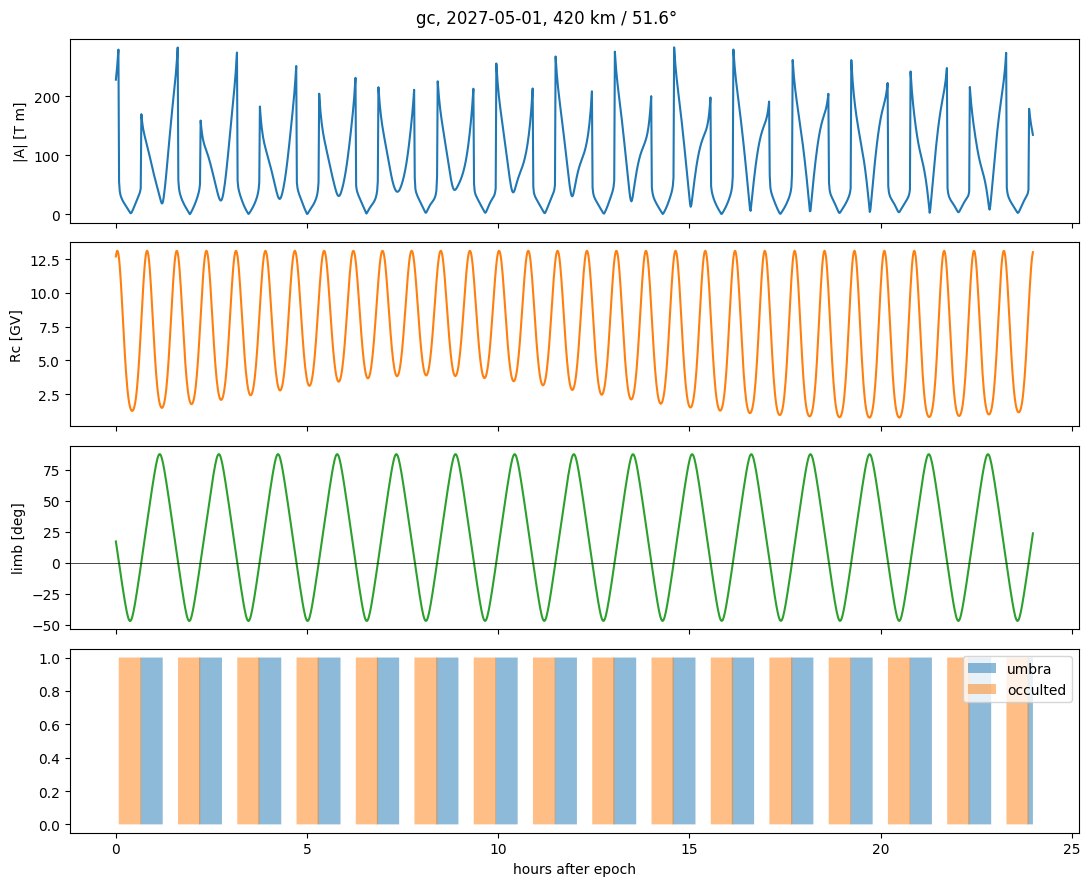

In [5]:
hours = t / 3600
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(hours, table["amp_tm"]); axes[0].set_ylabel("|A| [T m]")
axes[1].plot(hours, table["cutoff_gv"], color="C1"); axes[1].set_ylabel("Rc [GV]")
axes[2].plot(hours, table["limb_deg"], color="C2"); axes[2].axhline(0, color="k", lw=0.5)
axes[2].set_ylabel("limb [deg]")
axes[3].fill_between(hours, 0, table["umbra"], step="mid", alpha=0.5, label="umbra")
axes[3].fill_between(hours, 0, table["occulted"], step="mid", alpha=0.5, label="occulted")
axes[3].legend(loc="upper right"); axes[3].set_xlabel("hours after epoch")
fig.suptitle(f"{TARGET}, {EPOCH[:10]}, {ALT_KM:.0f} km / {INC_DEG}°")
plt.tight_layout()

## 5. Is the kernel separable from the background proxy?

usable sky frames 513  corr(K, Rc) = +0.74  corr(K, limb) = -0.87


Text(0, 0.5, 'K [T^2 m^2]')

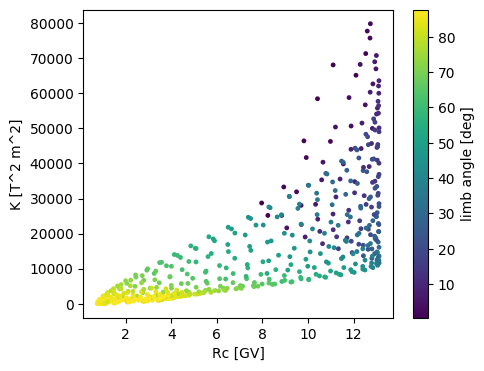

In [6]:
sky = ~table["occulted"] & table["umbra"]
rho = np.corrcoef(table["k_t2m2"][sky], table["cutoff_gv"][sky])[0, 1]
rho_limb = np.corrcoef(table["k_t2m2"][sky], table["limb_deg"][sky])[0, 1]
print(f"usable sky frames {sky.sum()}  corr(K, Rc) = {rho:+.2f}  corr(K, limb) = {rho_limb:+.2f}")
plt.figure(figsize=(5, 4))
plt.scatter(table["cutoff_gv"][sky], table["k_t2m2"][sky], s=6, c=table["limb_deg"][sky])
plt.colorbar(label="limb angle [deg]"); plt.xlabel("Rc [GV]"); plt.ylabel("K [T^2 m^2]")

## 6. What the boresight sees at one sample

Text(0.5, 1.0, 'gc at +1.1 h, maglat -53, limb 88 deg')

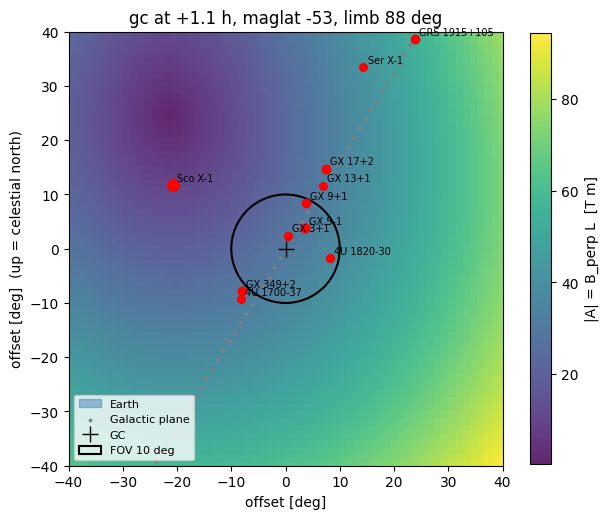

In [7]:
import sys; sys.path.append("../scripts")
from fov_view import fov_view
k = int(np.argmax(np.where(sky, table["limb_deg"], -1e9)))   # highest above the limb
time = frames.times(EPOCH, t[k])[0]
coeffs = field.load_igrf(float(frames.decimal_year(time)))
ax = fov_view(r[k], time, n[k], coeffs, lmax=LMAX)
ax.set_title(f"{TARGET} at +{t[k]/3600:.1f} h, maglat {table['maglat_deg'][k]:.0f}, limb {table['limb_deg'][k]:.0f} deg")